In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import PrecisionRecallDisplay

In [2]:
# df_original = pd.read_csv('Children Recode_final.csv')
# df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
# df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
# df.head()

# X = df.drop(columns=['Malnurished'])
# y = df['Malnurished']

# # Train-test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state= 12)

# # Columns to scale
# columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
# scaler = StandardScaler()

# # Make copies of training and test sets
# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

# # Scale only selected columns
# X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
# X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

# # Apply SMOTE
# sm = SMOTE(random_state=42)
# X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

# # Train Random Forest
# rf = RandomForestClassifier(
#     class_weight='balanced',    # To account for remaining imbalance
#     n_estimators=100,
#     max_depth=10,
#     min_samples_leaf=5
# )

# rf.fit(X_train_sm, y_train_sm)


# # Predict on test set
# y_pred = rf.predict(X_test_scaled)

# # Evaluate
# print("Classification Report on Test Set:")
# print(classification_report(y_test, y_pred))

In [3]:

# Load Data
df_original = pd.read_csv('df.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)

# Train-test Split
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state = 42)

In [4]:


print(df.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(2205, 37)
Malnurished
0    1168
1     596
Name: count, dtype: int64
Malnurished
0    292
1    149
Name: count, dtype: int64


In [5]:
columns_to_scale = ['Child_age', 'BMI', 'Mother_age_current']
scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

**Model**

In [6]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for GridSearchCV tuned to improve recall
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Initialize the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

# Setup GridSearchCV: use 'recall' as the scoring metric
grid_search = GridSearchCV(estimator=rf_classifier,
                           param_grid=param_grid,
                           scoring='recall',
                           cv=5,
                           n_jobs=-1,
                           verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Display best parameters and best recall score from CV
print("Best Parameters:", grid_search.best_params_)
print("Best Recall Score (CV):", grid_search.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Recall Score (CV): 0.412829131652661


In [13]:

rf = RandomForestClassifier(class_weight = 'balanced_subsample', max_depth =10, max_features = 'log2', min_samples_leaf = 2, min_samples_split = 5, n_estimators = 100, random_state=42)

# Fit the model to the training data
rf.fit(X_train, y_train)

# Step 6: Make predictions on the testing set
y_pred = rf.predict(X_test)

# Step 7: Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)



Accuracy: 0.6439909297052154
Confusion Matrix:
 [[220  72]
 [ 85  64]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.75      0.74       292
           1       0.47      0.43      0.45       149

    accuracy                           0.64       441
   macro avg       0.60      0.59      0.59       441
weighted avg       0.64      0.64      0.64       441



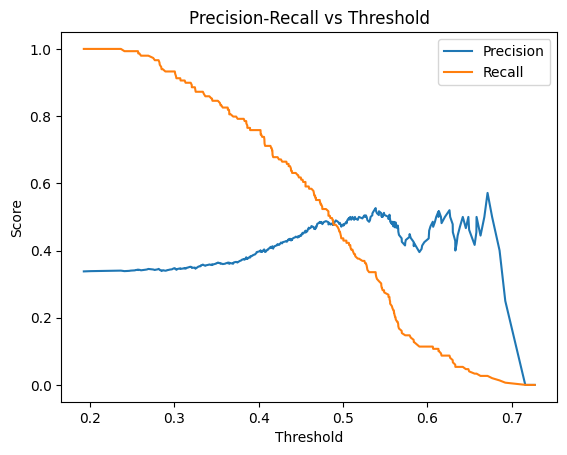

In [ ]:
from sklearn.metrics import precision_recall_curve

y_probas = rf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.show()


In [ ]:
y_probas = rf.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_probas_custom)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Confusion Matrix: 
col_0          0    1
Malnurished          
0            121  171
1             36  113

Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.41      0.54       292
           1       0.40      0.76      0.52       149

    accuracy                           0.53       441
   macro avg       0.58      0.59      0.53       441
weighted avg       0.64      0.53      0.53       441




### Average precision

In [ ]:
from sklearn.metrics import average_precision_score

print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.44114452416728683


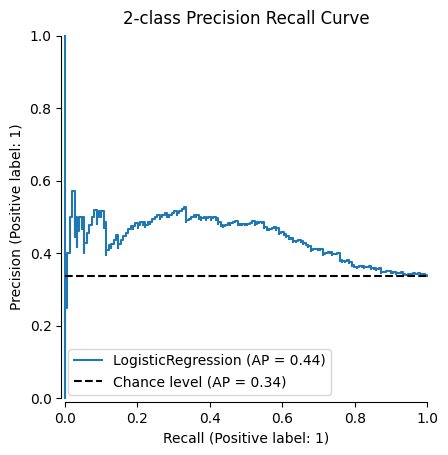

In [ ]:
display = PrecisionRecallDisplay.from_estimator(
    rf,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
    despine = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

## Feature selection

In [ ]:
# Display the feature importance
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print(importance_df)

                            Feature  Importance
1                               BMI    0.171154
0                         Child_age    0.143454
4                Mother_age_current    0.122317
2                   Children_under5    0.055388
3          Total_children_ever_born    0.030038
12            Place_residence_rural    0.029739
6                Mother_education_2    0.027820
31                 Child_sex_female    0.026995
33             Father_education_2.0    0.022767
25      Ethnicity_other terai caste    0.022526
32             Father_education_1.0    0.022006
29          Ethnicity_hill janajati    0.021416
17          Region_karnali province    0.020600
10                   Wealth_index_3    0.020202
13          Region_madhesh province    0.019680
5                Mother_education_1    0.018948
8                    Wealth_index_1    0.017833
16          Region_lumbini province    0.017045
11                   Wealth_index_4    0.015879
9                    Wealth_index_2    0

## Optional 

### ROC-AUC Curve

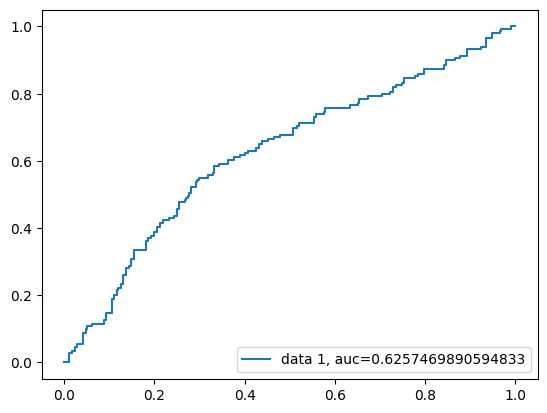

In [ ]:
y_probas_custom = rf.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_probas_custom)
auc = metrics.roc_auc_score(y_test, y_probas_custom)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()